# AI House Price Prediction System

## Notebook 02 - Data Cleaning

### Objective
Clean the Bengaluru House Price Dataset and prepare it for Machine Learning.

### Steps
1. Load Dataset
2. Check Missing Values
3. Remove Duplicates
4. Handle Missing Values
5. Clean `size`
6. Clean `total_sqft`
7. Handle Rare Locations
8. Remove Outliers
9. Save Clean Dataset

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/raw/Bengaluru_House_Data.csv")

df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df_clean = df.copy()

df_clean.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
print("Original Shape :", df.shape)
print("Working Shape  :", df_clean.shape)

Original Shape : (13320, 9)
Working Shape  : (13320, 9)


In [6]:

# Missing Values Report

missing = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Percentage": (df_clean.isnull().sum()/len(df_clean)*100).round(2)
})

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
society,5502,41.31
balcony,609,4.57
bath,73,0.55
size,16,0.12
location,1,0.01
area_type,0,0.00
availability,0,0.00
total_sqft,0,0.00
price,0,0.00


In [7]:
df_clean.isnull().sum().sum()

np.int64(6201)

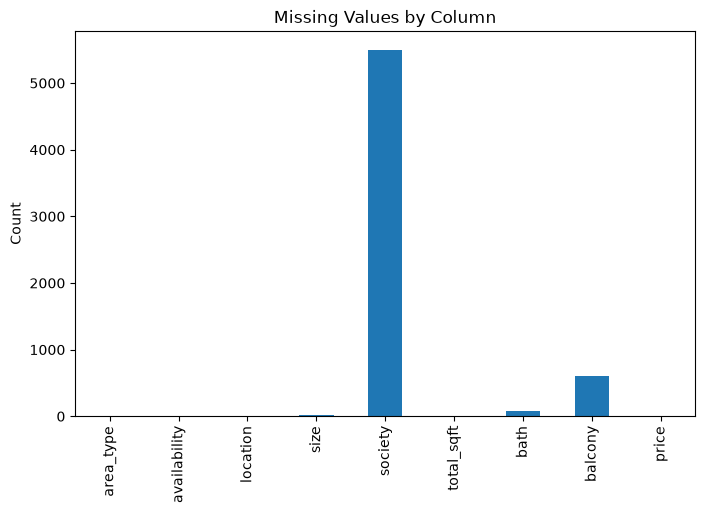

In [8]:
import matplotlib.pyplot as plt

missing["Missing Values"].plot(
    kind="bar",
    figsize=(8,5),
    title="Missing Values by Column"
)

plt.ylabel("Count")
plt.show()

In [9]:
duplicates = df_clean.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 529


In [10]:
missing[missing["Missing Values"] > 0]

,Missing Values,Percentage
location,1,0.01
size,16,0.12
society,5502,41.31
bath,73,0.55
balcony,609,4.57


In [11]:
df_clean["society"].isnull().sum()

np.int64(5502)

In [12]:
df_clean["society"].nunique()

2688

In [13]:
df_clean["society"].value_counts().head(10)

society
GrrvaGr    80
PrarePa    76
Sryalan    59
Prtates    59
GMown E    56
Bhmesy     51
Prtanha    51
Prityel    50
Prarkun    49
PrityTr    49
Name: count, dtype: int64

In [14]:
df_clean["balcony"].describe()

count    12711.000000
mean         1.584376
std          0.817263
min          0.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          3.000000
Name: balcony, dtype: float64

In [15]:
df_clean["balcony"].value_counts().sort_index()

balcony
0.0    1029
1.0    4897
2.0    5113
3.0    1672
Name: count, dtype: int64

In [16]:
df_clean["bath"].describe()

count    13247.000000
mean         2.692610
std          1.341458
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         40.000000
Name: bath, dtype: float64

In [17]:
df_clean["bath"].value_counts().sort_index()

bath
1.0      788
2.0     6908
3.0     3286
4.0     1226
5.0      524
6.0      273
7.0      102
8.0       64
9.0       43
10.0      13
11.0       3
12.0       7
13.0       3
14.0       1
15.0       1
16.0       2
18.0       1
27.0       1
40.0       1
Name: count, dtype: int64

In [18]:
missing

,Missing Values,Percentage
area_type,0,0.00
availability,0,0.00
location,1,0.01
size,16,0.12
society,5502,41.31
total_sqft,0,0.00
bath,73,0.55
balcony,609,4.57
price,0,0.00


In [19]:
duplicates

np.int64(529)

In [20]:
df_clean["society"].isnull().sum()

np.int64(5502)

In [21]:
df_clean["balcony"].isnull().sum()

np.int64(609)

In [22]:
print("Before:", df_clean.shape)

df_clean = df_clean.drop_duplicates()

print("After :", df_clean.shape)

Before: (13320, 9)
After : (12791, 9)


In [23]:
df_clean = df_clean.drop(columns=["society"])

In [24]:
df_clean = df_clean.dropna(subset=["location", "size", "bath"])

In [25]:
median_balcony = df_clean["balcony"].median()

df_clean["balcony"] = df_clean["balcony"].fillna(median_balcony)

In [26]:
df_clean.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [27]:
df_clean.shape

(12717, 8)

In [28]:
df_clean.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [29]:
df_clean["size"].unique()[:20]

<ArrowStringArray>
[    '2 BHK', '4 Bedroom',     '3 BHK',     '4 BHK', '6 Bedroom', '3 Bedroom',
     '1 BHK',      '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom', '7 Bedroom',
     '5 BHK',     '7 BHK',     '6 BHK', '5 Bedroom',    '11 BHK',     '9 BHK',
 '9 Bedroom',    '27 BHK']
Length: 20, dtype: str

In [30]:
df_clean["size"].value_counts().head(20)

size
2 BHK         4930
3 BHK         4096
4 Bedroom      816
4 BHK          560
3 Bedroom      534
1 BHK          514
2 Bedroom      314
5 Bedroom      290
6 Bedroom      191
1 Bedroom      104
8 Bedroom       84
7 Bedroom       82
5 BHK           57
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
Name: count, dtype: int64

In [31]:
df_clean["size"].head()

0        2 BHK
1    4 Bedroom
2        3 BHK
3        3 BHK
4        2 BHK
Name: size, dtype: str

In [32]:
df_clean["bhk"] = df_clean["size"].str.split().str[0].astype(int)

In [33]:
df_clean[["size", "bhk"]].head(15)

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2
5,2 BHK,2
6,4 BHK,4
7,4 BHK,4
8,3 BHK,3
9,6 Bedroom,6


In [34]:
df_clean["bhk"].dtype

dtype('int64')

In [35]:
df_clean["bhk"].value_counts().sort_index()

bhk
1      631
2     5244
3     4630
4     1376
5      347
6      221
7       99
8       89
9       54
10      14
11       4
12       1
13       1
14       1
16       1
18       1
19       1
27       1
43       1
Name: count, dtype: int64

In [36]:
df_clean["total_sqft"].sample(20, random_state=42)

6413     2108
1850     1180
3715     1240
12897    1571
11857    1145
10539     925
2239     3000
8400      808
12298    1153
6158     1597
659      1260
9646     1800
8750     1152
8498     1057
9827      750
7836      950
7613     1495
9758     2185
2455     1135
2355     2400
Name: total_sqft, dtype: str

In [37]:
df_clean["total_sqft"].dtype

<StringDtype(na_value=nan)>

In [38]:
df_clean["total_sqft"].unique()[:50]

<ArrowStringArray>
[       '1056',        '2600',        '1440',        '1521',        '1200',
        '1170',        '2732',        '3300',        '1310',        '1020',
        '1800',        '2785',        '1000',        '1100',        '2250',
        '1175',        '1180',        '1540',        '2770',         '600',
        '1755',        '2800',        '1767',         '510',        '1250',
         '660',        '1610',        '1151',        '1025', '2100 - 2850',
        '1075',        '1760',        '1693',        '1925',         '700',
        '1070',        '1724',        '1290',        '1143',        '1296',
        '1254',     '1330.74',         '970',        '1459',         '800',
         '869',        '1270',        '1670',        '2010',        '1185']
Length: 50, dtype: str

In [39]:
for value in df_clean["total_sqft"].unique():
    if "-" in str(value):
        print(value)

2100 - 2850
3067 - 8156
1042 - 1105
1145 - 1340
1015 - 1540
1195 - 1440
1120 - 1145
3090 - 5002
1160 - 1195
1115 - 1130
520 - 645
1000 - 1285
650 - 665
633 - 666
1445 - 1455
884 - 1116
850 - 1093
547.34 - 827.31
580 - 650
3425 - 3435
1804 - 2273
3630 - 3800
4000 - 5249
1250 - 1305
670 - 980
1005.03 - 1252.49
1004 - 1204
645 - 936
2710 - 3360
2830 - 2882
596 - 804
1255 - 1863
1300 - 1405
934 - 1437
980 - 1030
2249.81 - 4112.19
1070 - 1315
2806 - 3019
613 - 648
704 - 730
1210 - 1477
3369 - 3464
1125 - 1500
1076 - 1199
381 - 535
524 - 894
540 - 670
2725 - 3250
888 - 1290
660 - 700
385 - 440
770 - 841
1469 - 1766
1255 - 1350
870 - 1080
2580 - 2591
2563 - 2733
605 - 624
1349 - 3324
3300 - 3335
1180 - 1630
1365 - 1700
981 - 1249
1565 - 1595
1270 - 1275
840 - 1010
655 - 742
1408 - 1455
942 - 1117
598 - 958
1010 - 1300
1450 - 1950
763 - 805
3307 - 3464
620 - 934
2462 - 2467
540 - 740
3508 - 4201
4900 - 4940
755 - 770
664 - 722
596 - 861
615 - 985
540 - 565
750 - 800
1660 - 1805
1079 - 1183
280

In [40]:
for value in df_clean["total_sqft"].unique():
    if any(char.isalpha() for char in str(value)):
        print(value)

34.46Sq. Meter
4125Perch
1000Sq. Meter
1100Sq. Yards
5.31Acres
30Acres
716Sq. Meter
1500Sq. Meter
142.61Sq. Meter
1574Sq. Yards
361.33Sq. Yards
117Sq. Yards
3040Sq. Meter
500Sq. Yards
167Sq. Meter
315Sq. Yards
3Cents
188.89Sq. Yards
204Sq. Meter
45Sq. Yards
133.3Sq. Yards
78.03Sq. Meter
122Sq. Yards
84.53Sq. Meter
2.09Acres
24Guntha
697Sq. Meter
1500Cents
132Sq. Yards
2Acres
1100Sq. Meter
15Acres
1.26Acres
151.11Sq. Yards
1Grounds
2940Sq. Yards
45.06Sq. Meter
1.25Acres
86.72Sq. Meter
38Guntha
6Acres
120Sq. Yards
24Sq. Meter
142.84Sq. Meter
300Sq. Yards


In [41]:
def convert_total_sqft(value):
    """
    Convert total_sqft values into float.

    Handles:
    - Normal values (1200)
    - Range values (1200-1500)
    - Returns None for unsupported units.
    """

    value = str(value).strip()

    # Case 1: Range (1200-1500)
    if "-" in value:
        start, end = value.split("-")
        return (float(start) + float(end)) / 2

    # Case 2: Normal number
    try:
        return float(value)
    except ValueError:
        return None

In [42]:
print(convert_total_sqft("1200"))
print(convert_total_sqft("2100-2850"))
print(convert_total_sqft("34.46Sq. Meter"))

1200.0
2475.0
None


In [43]:
df_clean["total_sqft"] = df_clean["total_sqft"].apply(convert_total_sqft)

In [44]:
df_clean["total_sqft"].isnull().sum()

np.int64(46)

In [45]:
df_clean = df_clean.dropna(subset=["total_sqft"])

In [46]:
df_clean["total_sqft"].dtype

dtype('float64')

In [47]:
df_clean.shape

(12671, 9)

In [48]:
df_clean["location"] = df_clean["location"].str.strip()

In [49]:
print("Unique Locations:", df_clean["location"].nunique())

Unique Locations: 1287


In [50]:
location_count = df_clean["location"].value_counts()

location_count.head(20)

location
Whitefield                  516
Sarjapur  Road              372
Electronic City             289
Kanakpura Road              240
Thanisandra                 230
Yelahanka                   207
Marathahalli                169
Hebbal                      160
Raja Rajeshwari Nagar       159
Uttarahalli                 157
Bannerghatta Road           148
Hennur Road                 147
7th Phase JP Nagar          134
Electronic City Phase II    127
Rajaji Nagar                106
Haralur Road                101
Bellandur                    93
KR Puram                     88
Hoodi                        88
Electronics City Phase 1     87
Name: count, dtype: int64

In [51]:
rare_locations = location_count[location_count <= 10]

print("Rare Locations:", len(rare_locations))

Rare Locations: 1055


In [52]:
df_clean["location"] = df_clean["location"].apply(
    lambda x: "Other" if x in rare_locations else x
)

In [53]:
df_clean["location"].nunique()

233

In [54]:
df_clean["price_per_sqft"] = (df_clean["price"] * 100000) / df_clean["total_sqft"]

In [55]:
df_clean[["price", "total_sqft", "price_per_sqft"]].head()

,price,total_sqft,price_per_sqft
0,39.07,1056.0,3699.810606
1,120.00,2600.0,4615.384615
2,62.00,1440.0,4305.555556
3,95.00,1521.0,6245.890861
4,51.00,1200.0,4250.000000


In [56]:
df_clean["price_per_sqft"].describe()

count    1.267100e+04
mean     8.037382e+03
std      1.089298e+05
min      2.678298e+02
25%      4.298768e+03
50%      5.483871e+03
75%      7.404795e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [57]:
df_clean = df_clean[df_clean["total_sqft"] / df_clean["bhk"] >= 300]

In [58]:
df_clean.shape

(11937, 10)

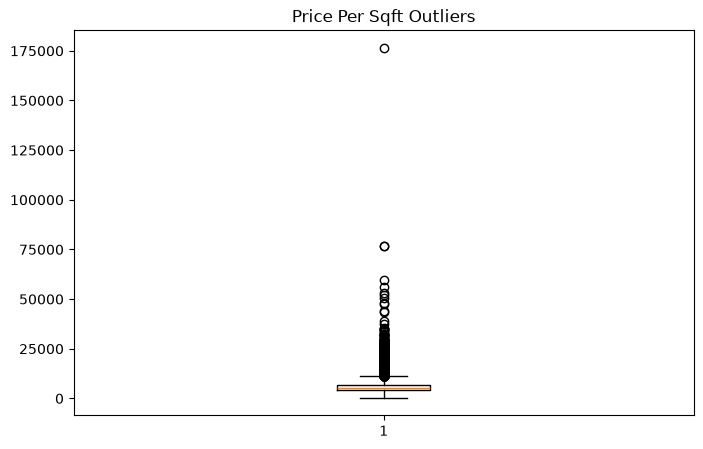

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(df_clean["price_per_sqft"])

plt.title("Price Per Sqft Outliers")

plt.show()

In [60]:
df_clean.to_csv(
    "../data/processed/bengaluru_house_cleaned.csv",
    index=False
)

In [61]:
import os

os.path.exists("../data/processed/bengaluru_house_cleaned.csv")

True

In [62]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.preprocessing import (
    remove_duplicates,
    drop_society,
    handle_missing_values,
)

In [63]:
import pandas as pd

df = pd.read_csv("../data/raw/Bengaluru_House_Data.csv")

df = remove_duplicates(df)
df = drop_society(df)
df = handle_missing_values(df)

df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [64]:
from src.preprocessing import *

df = pd.read_csv("../data/raw/Bengaluru_House_Data.csv")

df = remove_duplicates(df)

df = drop_society(df)

df = handle_missing_values(df)

df.shape

(12717, 8)

In [65]:
df.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64